# Data Preprocessing & Feature Analysis
This notebook merges tournament matchup data with team season stats,
then analyzes which features are most predictive of tournament game outcomes.

**Data Sources:**
- ESPN: Tournament game results (2014-2024, excl. 2020)
- Sports-Reference: Team season stats (basic + advanced)

**Goal:** Identify the strongest predictors of tournament game winners from 27 candidate features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data/raw')
YEARS = [2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]  # skip 2020 (COVID)

## 1. Load & Merge Data
For each tournament game, attach both teams' season stats. Then compute the **differential**
(home - away) for each stat — this is what the model will use to predict the winner.

In [2]:
# Columns we want from Sports-Reference, mapped to clean names
SR_COLUMNS = {
    'School': 'school',
    'Overall_W-L%': 'win_pct',
    'Overall_SRS': 'srs',
    'Overall_SOS': 'sos',
    'School Advanced_ORtg': 'ortg',
    'School Advanced_eFG%': 'efg_pct',
    'School Advanced_TOV%': 'tov_pct',
    'School Advanced_ORB%': 'orb_pct',
    'School Advanced_Pace': 'pace',
    'School Advanced_FTr': 'ftr',
    'School Advanced_TS%': 'ts_pct',
    'Totals_FT%': 'ft_pct',
    'Points_Tm.': 'pts_for',
    'Points_Opp.': 'pts_against',
    'School Advanced_AST%': 'ast_pct',
    'School Advanced_STL%': 'stl_pct',
    'School Advanced_BLK%': 'blk_pct',
    'School Advanced_TRB%': 'trb_pct',
    'School Advanced_3PAr': 'three_par',
    'School Advanced_FT/FGA': 'ft_fga',
    'Totals_FG%': 'fg_pct',
    'Totals_3P%': 'three_pct',
    'Totals_3P': 'three_made',
    'Totals_TRB': 'trb',
    'Totals_AST': 'ast',
    'Totals_STL': 'stl',
    'Totals_BLK': 'blk',
    'Totals_TOV': 'tov',
}

STAT_COLS = [v for v in SR_COLUMNS.values() if v != 'school']
print(f'{len(STAT_COLS)} features selected')

27 features selected


In [3]:
# Load and merge all seasons
all_matchups = []

for year in YEARS:
    # Load tournament games
    tourney = pd.read_csv(DATA_DIR / f'espn_tournament_{year}.csv')
    
    # Load team stats
    sr = pd.read_csv(DATA_DIR / f'sportsref_combined_{year}.csv')
    sr = sr[list(SR_COLUMNS.keys())].rename(columns=SR_COLUMNS)
    
    # Convert stats to numeric
    for col in STAT_COLS:
        sr[col] = pd.to_numeric(sr[col], errors='coerce')
    
    # Merge: need to match ESPN team names to SportsRef school names
    # We'll do a fuzzy join - first try exact, then strip common suffixes
    tourney['season'] = year
    
    # Add home team stats
    home_stats = sr.copy()
    home_stats.columns = ['school'] + [f'home_{c}' for c in STAT_COLS]
    
    # Add away team stats
    away_stats = sr.copy()
    away_stats.columns = ['school'] + [f'away_{c}' for c in STAT_COLS]
    
    all_matchups.append({
        'tourney': tourney,
        'home_stats': home_stats,
        'away_stats': away_stats,
        'year': year
    })

print(f'Loaded {len(all_matchups)} seasons')

Loaded 10 seasons


In [4]:
# Name matching between ESPN and Sports-Reference
# ESPN uses full names like "Duke Blue Devils", SportsRef uses "Duke"
# Build a mapping by extracting the location/school part

def normalize_name(espn_name):
    """Convert ESPN full name to match Sports-Reference school name."""
    # Common mappings that don't follow simple rules
    manual = {
        'UConn Huskies': 'Connecticut',
        'UConn': 'Connecticut',
        'UCF Knights': 'UCF',
        'UNLV Rebels': 'UNLV',
        'USC Trojans': 'Southern California',
        'LSU Tigers': 'Louisiana State',
        'SMU Mustangs': 'SMU',
        'VCU Rams': 'Virginia Commonwealth',
        'BYU Cougars': 'Brigham Young',
        'Ole Miss Rebels': 'Mississippi',
        'Pitt Panthers': 'Pittsburgh',
        'Miami Hurricanes': 'Miami (FL)',
        'Saint Mary\'s Gaels': "Saint Mary's (CA)",
        'NC State Wolfpack': 'North Carolina State',
        'ETSU Buccaneers': 'East Tennessee State',
        'Long Beach State Beach': 'Long Beach State',
        'South Dakota State Jackrabbits': 'South Dakota State',
        'Saint Peter\'s Peacocks': "Saint Peter's",
        'FDU Knights': 'Fairleigh Dickinson',
        'UAB Blazers': 'UAB',
        'UCSB Gauchos': 'UC Santa Barbara',
        'UNC Asheville Bulldogs': 'UNC Asheville',
        'UNC Wilmington Seahawks': 'UNC Wilmington',
        'UT Arlington Mavericks': 'UT Arlington',
        'Texas A&M Aggies': 'Texas A&M',
        'Texas A&M-CC Islanders': 'Texas A&M-Corpus Christi',
        'App State Mountaineers': 'Appalachian State',
        'Cal State Fullerton Titans': 'Cal State Fullerton',
        'South Florida Bulls': 'South Florida',
        'Western Kentucky Hilltoppers': 'Western Kentucky',
        'Loyola Chicago Ramblers': 'Loyola (IL)',
        'Loyola-Chicago Ramblers': 'Loyola (IL)',
        'Murray State Racers': 'Murray State',
        'Green Bay Phoenix': 'Green Bay',
        'Little Rock Trojans': 'Little Rock',
        'Middle Tennessee Blue Raiders': 'Middle Tennessee',
        'Northern Kentucky Norse': 'Northern Kentucky',
        'Jacksonville State Gamecocks': 'Jacksonville State',
        'Montana State Bobcats': 'Montana State',
    }
    if espn_name in manual:
        return manual[espn_name]
    
    # Try removing common mascot names (last word)
    parts = espn_name.rsplit(' ', 1)
    if len(parts) == 2:
        return parts[0]
    return espn_name

# Test the mapping
test_names = ['Duke Blue Devils', 'UConn Huskies', 'NC State Wolfpack', 'Kansas Jayhawks']
for n in test_names:
    print(f'  {n} -> {normalize_name(n)}')

  Duke Blue Devils -> Duke Blue
  UConn Huskies -> Connecticut
  NC State Wolfpack -> North Carolina State
  Kansas Jayhawks -> Kansas


In [5]:
# Build the full matchup dataset with differentials
rows = []
unmatched = set()

for data in all_matchups:
    tourney = data['tourney']
    home_stats = data['home_stats']
    away_stats = data['away_stats']
    year = data['year']
    
    for _, game in tourney.iterrows():
        home_name = normalize_name(str(game['home_team_name']))
        away_name = normalize_name(str(game['away_team_name']))
        
        home_match = home_stats[home_stats['school'] == home_name]
        away_match = away_stats[away_stats['school'] == away_name]
        
        if home_match.empty:
            unmatched.add((year, game['home_team_name'], home_name))
            continue
        if away_match.empty:
            unmatched.add((year, game['away_team_name'], away_name))
            continue
        
        row = {
            'season': year,
            'round': game['round'],
            'home_team': game['home_team_name'],
            'away_team': game['away_team_name'],
            'home_seed': game['home_seed'],
            'away_seed': game['away_seed'],
            'home_score': int(game['home_score']),
            'away_score': int(game['away_score']),
            'home_win': 1 if int(game['home_score']) > int(game['away_score']) else 0,
        }
        
        # Add individual team stats
        for col in STAT_COLS:
            row[f'home_{col}'] = home_match.iloc[0][f'home_{col}']
            row[f'away_{col}'] = away_match.iloc[0][f'away_{col}']
        
        # Add differentials (home - away)
        for col in STAT_COLS:
            h = home_match.iloc[0][f'home_{col}']
            a = away_match.iloc[0][f'away_{col}']
            row[f'diff_{col}'] = h - a if pd.notna(h) and pd.notna(a) else np.nan
        
        rows.append(row)

df = pd.DataFrame(rows)
print(f'Total matchups: {len(df)}')
print(f'Unmatched teams: {len(unmatched)}')
if unmatched:
    for year, espn, norm in sorted(unmatched):
        print(f'  {year}: "{espn}" -> "{norm}"')

Total matchups: 477
Unmatched teams: 93
  2014: "American University Eagles" -> "American University"
  2014: "Arizona State Sun Devils" -> "Arizona State Sun"
  2014: "Delaware Blue Hens" -> "Delaware Blue"
  2014: "Duke Blue Devils" -> "Duke Blue"
  2014: "Louisiana Ragin' Cajuns" -> "Louisiana Ragin'"
  2014: "NC State Wolfpack" -> "North Carolina State"
  2014: "North Carolina Tar Heels" -> "North Carolina Tar"
  2014: "Tulsa Golden Hurricane" -> "Tulsa Golden"
  2014: "UAlbany Great Danes" -> "UAlbany Great"
  2015: "Duke Blue Devils" -> "Duke Blue"
  2015: "NC State Wolfpack" -> "North Carolina State"
  2015: "North Carolina Tar Heels" -> "North Carolina Tar"
  2015: "Notre Dame Fighting Irish" -> "Notre Dame Fighting"
  2015: "SMU Mustangs" -> "SMU"
  2015: "St. John's Red Storm" -> "St. John's Red"
  2015: "UAlbany Great Danes" -> "UAlbany Great"
  2016: "California Golden Bears" -> "California Golden"
  2016: "Duke Blue Devils" -> "Duke Blue"
  2016: "Fairleigh Dickinson Knigh

In [6]:
# Show the matchup dataset
print(f'Shape: {df.shape}')
print(f'Home win rate: {df["home_win"].mean():.3f}')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'Games per season:')
print(df['season'].value_counts().sort_index().to_string())
df.head(10)

Shape: (477, 90)
Home win rate: 0.671
Seasons: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Games per season:
season
2014    55
2015    48
2016    50
2017    49
2018    42
2019    45
2021    51
2022    48
2023    47
2024    42


,season,round,home_team,away_team,home_seed,away_seed,home_score,away_score,home_win,home_win_pct,away_win_pct,home_srs,away_srs,home_sos,away_sos,home_ortg,away_ortg,home_efg_pct,away_efg_pct,home_tov_pct,away_tov_pct,home_orb_pct,away_orb_pct,home_pace,away_pace,home_ftr,away_ftr,home_ts_pct,away_ts_pct,home_ft_pct,away_ft_pct,home_pts_for,away_pts_for,home_pts_against,away_pts_against,home_ast_pct,away_ast_pct,home_stl_pct,away_stl_pct,home_blk_pct,away_blk_pct,home_trb_pct,away_trb_pct,home_three_par,away_three_par,home_ft_fga,away_ft_fga,home_fg_pct,away_fg_pct,home_three_pct,away_three_pct,home_three_made,away_three_made,home_trb,away_trb,home_ast,away_ast,home_stl,away_stl,home_blk,away_blk,home_tov,away_tov,diff_win_pct,diff_srs,diff_sos,diff_ortg,diff_efg_pct,diff_tov_pct,diff_orb_pct,diff_pace,diff_ftr,diff_ts_pct,diff_ft_pct,diff_pts_for,diff_pts_against,diff_ast_pct,diff_stl_pct,diff_blk_pct,diff_trb_pct,diff_three_par,diff_ft_fga,diff_fg_pct,diff_three_pct,diff_three_made,diff_trb,diff_ast,diff_stl,diff_blk,diff_tov
0,2014,F4,Texas Southern Tigers,Cal Poly Mustangs,16,16,69,81,0,0.559,0.412,-8.41,-1.34,-10.07,1.69,109.8,103.5,0.521,0.466,16.6,12.4,33.8,31.8,68.2,60.8,0.491,0.326,0.565,0.501,0.718,0.688,2584,2141,2512,2163,55.5,52.3,6.6,9.6,8.5,8.0,52.2,48.8,0.325,0.354,0.352,0.224,0.462,0.408,0.360,0.333,217,218,1246,1096,476,394,155,198,124,93,454,303,0.147,-7.07,-11.76,6.3,0.055,4.2,2.0,7.4,0.165,0.064,0.030,443,349,3.2,-3.0,0.5,3.4,-0.029,0.128,0.054,0.027,-1,150,82,-43,31,151
1,2014,F4,Tennessee Volunteers,Iowa Hawkeyes,11,11,78,65,1,0.649,0.606,17.34,18.58,7.84,7.43,114.2,115.0,0.503,0.511,13.7,13.3,39.8,37.7,62.8,69.8,0.416,0.453,0.545,0.558,0.719,0.735,2672,2689,2283,2321,50.9,57.9,8.2,10.0,12.0,13.5,56.2,54.7,0.308,0.275,0.299,0.333,0.453,0.463,0.325,0.350,205,191,1424,1332,472,532,192,234,172,164,388,371,0.043,-1.24,0.41,-0.8,-0.008,0.4,2.1,-7.0,-0.037,-0.013,-0.016,-17,-38,-7.0,-1.8,-1.5,1.5,0.033,-0.034,-0.010,-0.025,14,92,-60,-42,8,17
2,2014,R64,Ohio State Buckeyes,Dayton Flyers,6,11,59,60,0,0.714,0.703,17.84,10.55,8.12,5.34,106.1,109.6,0.503,0.524,14.9,15.5,29.6,34.0,65.0,65.4,0.423,0.406,0.540,0.555,0.689,0.681,2432,2671,2092,2478,49.9,51.9,11.8,9.1,12.2,7.3,50.2,52.7,0.329,0.319,0.291,0.277,0.450,0.463,0.324,0.377,200,243,1187,1289,421,485,270,222,157,96,394,442,0.011,7.29,2.78,-3.5,-0.021,-0.6,-4.4,-0.4,0.017,-0.015,0.008,-239,-386,-2.0,2.7,4.9,-2.5,0.010,0.014,-0.013,-0.053,-43,-102,-64,48,61,-48
3,2014,R64,Colorado Buffaloes,Pittsburgh Panthers,8,9,48,77,0,0.657,0.722,10.80,17.46,8.80,7.54,103.7,113.0,0.483,0.507,16.8,13.7,34.0,37.3,67.0,62.5,0.483,0.443,0.534,0.550,0.718,0.712,2457,2586,2387,2229,48.8,62.9,8.7,11.1,9.0,8.6,54.3,54.5,0.304,0.269,0.346,0.315,0.435,0.460,0.318,0.351,181,183,1305,1291,397,563,207,254,115,107,466,373,-0.065,-6.66,1.26,-9.3,-0.024,3.1,-3.3,4.5,0.040,-0.016,0.006,-129,158,-14.1,-2.4,0.4,-0.2,0.035,0.031,-0.025,-0.033,-2,14,-166,-47,8,93
4,2014,R64,Cincinnati Bearcats,Harvard Crimson,5,12,57,61,0,0.794,0.844,15.26,10.79,5.28,-0.47,107.6,111.6,0.477,0.519,14.4,15.0,39.1,32.8,63.6,64.6,0.387,0.480,0.519,0.564,0.708,0.724,2325,2343,1986,1952,52.8,57.1,12.4,11.6,16.0,13.4,53.2,52.1,0.309,0.283,0.274,0.347,0.425,0.465,0.335,0.385,196,184,1224,1092,425,449,268,243,188,155,377,365,-0.050,4.47,5.75,-4.0,-0.042,-0.6,6.3,-1.0,-0.093,-0.045,-0.016,-18,34,-4.3,0.8,2.6,1.1,0.026,-0.073,-0.040,-0.050,12,132,-24,25,33,12
5,2014,R64,Syracuse Orange,Western Michigan Broncos,3,14,77,53,1,0.824,0.697,16.05,1.73,7.25,-1.45,111.6,106.5,0.482,0.520,12.1,18.2,38.1,31.6,60.5,66.5,0.382,0.508,0.522,0.568,0.708,0.724,2311,2373,2012,2235,49.1,48.3,13.1,8.7,17.2,9.6,52.8,51.3,0.270,0.352,0.270,0.368,0.437,0.463,0.331,0.329,167,195,1200,1143,402,376,271,194,171,111,306,464,0.127,14.32,8.70,5.1,-0.038,-6.1,6.5,-6.0,-0.126,-0.046,-0.016,-62,-223,0.8,4.4,7.6,1.5,-0.082,-0.098,-0.026,0.002,-28,57,26,77,60,-158
6,2014,R64,Oregon Ducks,BYU Cougars,7,10,87,68,1,0.706,0.657,15.75,11.63,8.05,5.72,115.0,111.

## 2. Correlation Analysis
How well does each stat differential correlate with the home team winning?

In [7]:
# Correlation of each differential feature with home_win
diff_cols = [f'diff_{c}' for c in STAT_COLS]
correlations = df[diff_cols + ['home_win']].corr()['home_win'].drop('home_win').sort_values(ascending=False)

# Clean up names for display
correlations.index = [c.replace('diff_', '') for c in correlations.index]

print('Correlation with home_win (stat differential):')
print('='*50)
for feat, corr in correlations.items():
    bar = '█' * int(abs(corr) * 50)
    sign = '+' if corr > 0 else '-'
    print(f'  {feat:15s} {sign}{abs(corr):.4f}  {bar}')

correlations

Correlation with home_win (stat differential):
  srs             +0.4212  █████████████████████
  pts_for         +0.4121  ████████████████████
  trb             +0.3497  █████████████████
  sos             +0.3192  ███████████████
  pts_against     +0.2862  ██████████████
  ast             +0.2657  █████████████
  win_pct         +0.2309  ███████████
  three_made      +0.2257  ███████████
  ortg            +0.1973  █████████
  blk             +0.1939  █████████
  stl             +0.1690  ████████
  ts_pct          +0.1177  █████
  tov             +0.1132  █████
  ft_pct          +0.1117  █████
  fg_pct          +0.1096  █████
  efg_pct         +0.1094  █████
  three_pct       +0.0991  ████
  blk_pct         +0.0774  ███
  trb_pct         +0.0541  ██
  orb_pct         +0.0445  ██
  stl_pct         +0.0397  █
  ast_pct         +0.0150  
  three_par       +0.0107  
  ft_fga          -0.0250  █
  ftr             -0.0653  ███
  pace            -0.1269  ██████
  tov_pct         -0.1606  ███

srs            0.421247
pts_for        0.412141
trb            0.349708
sos            0.319207
pts_against    0.286206
ast            0.265709
win_pct        0.230919
three_made     0.225694
ortg           0.197303
blk            0.193917
stl            0.169042
ts_pct         0.117673
tov            0.113216
ft_pct         0.111746
fg_pct         0.109601
efg_pct        0.109439
three_pct      0.099101
blk_pct        0.077419
trb_pct        0.054067
orb_pct        0.044489
stl_pct        0.039703
ast_pct        0.015022
three_par      0.010730
ft_fga        -0.024988
ftr           -0.065268
pace          -0.126927
tov_pct       -0.160649
Name: home_win, dtype: float64

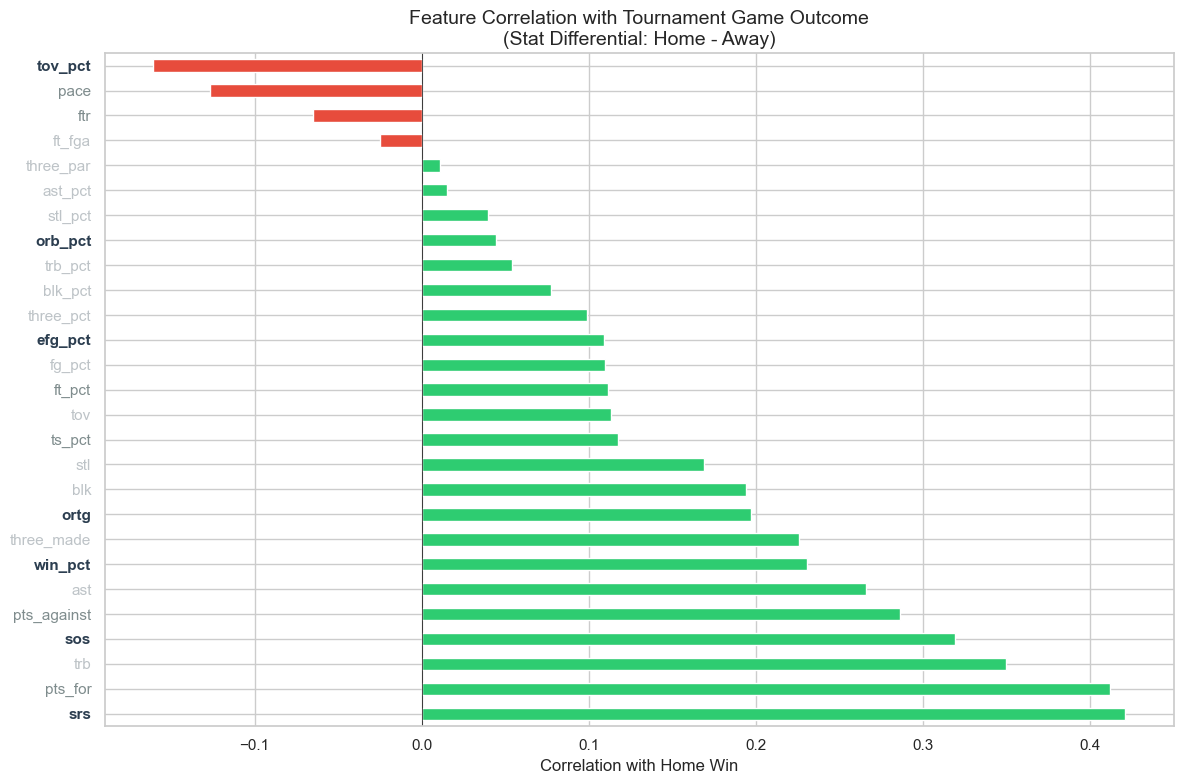

In [8]:
# Bar chart of correlations with home_win
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)

ax.set_xlabel('Correlation with Home Win', fontsize=12)
ax.set_title('Feature Correlation with Tournament Game Outcome\n(Stat Differential: Home - Away)', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.5)

# Add tier labels
tier1 = ['srs', 'win_pct', 'sos', 'ortg', 'efg_pct', 'tov_pct', 'orb_pct']
tier2 = ['pace', 'ftr', 'ts_pct', 'ft_pct', 'pts_for', 'pts_against']
for label in ax.get_yticklabels():
    name = label.get_text()
    if name in tier1:
        label.set_fontweight('bold')
        label.set_color('#2c3e50')
    elif name in tier2:
        label.set_color('#7f8c8d')
    else:
        label.set_color('#bdc3c7')

plt.tight_layout()
plt.savefig('../results/visualizations/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlation Matrix (Feature-to-Feature)
Check for multicollinearity — highly correlated features may be redundant.

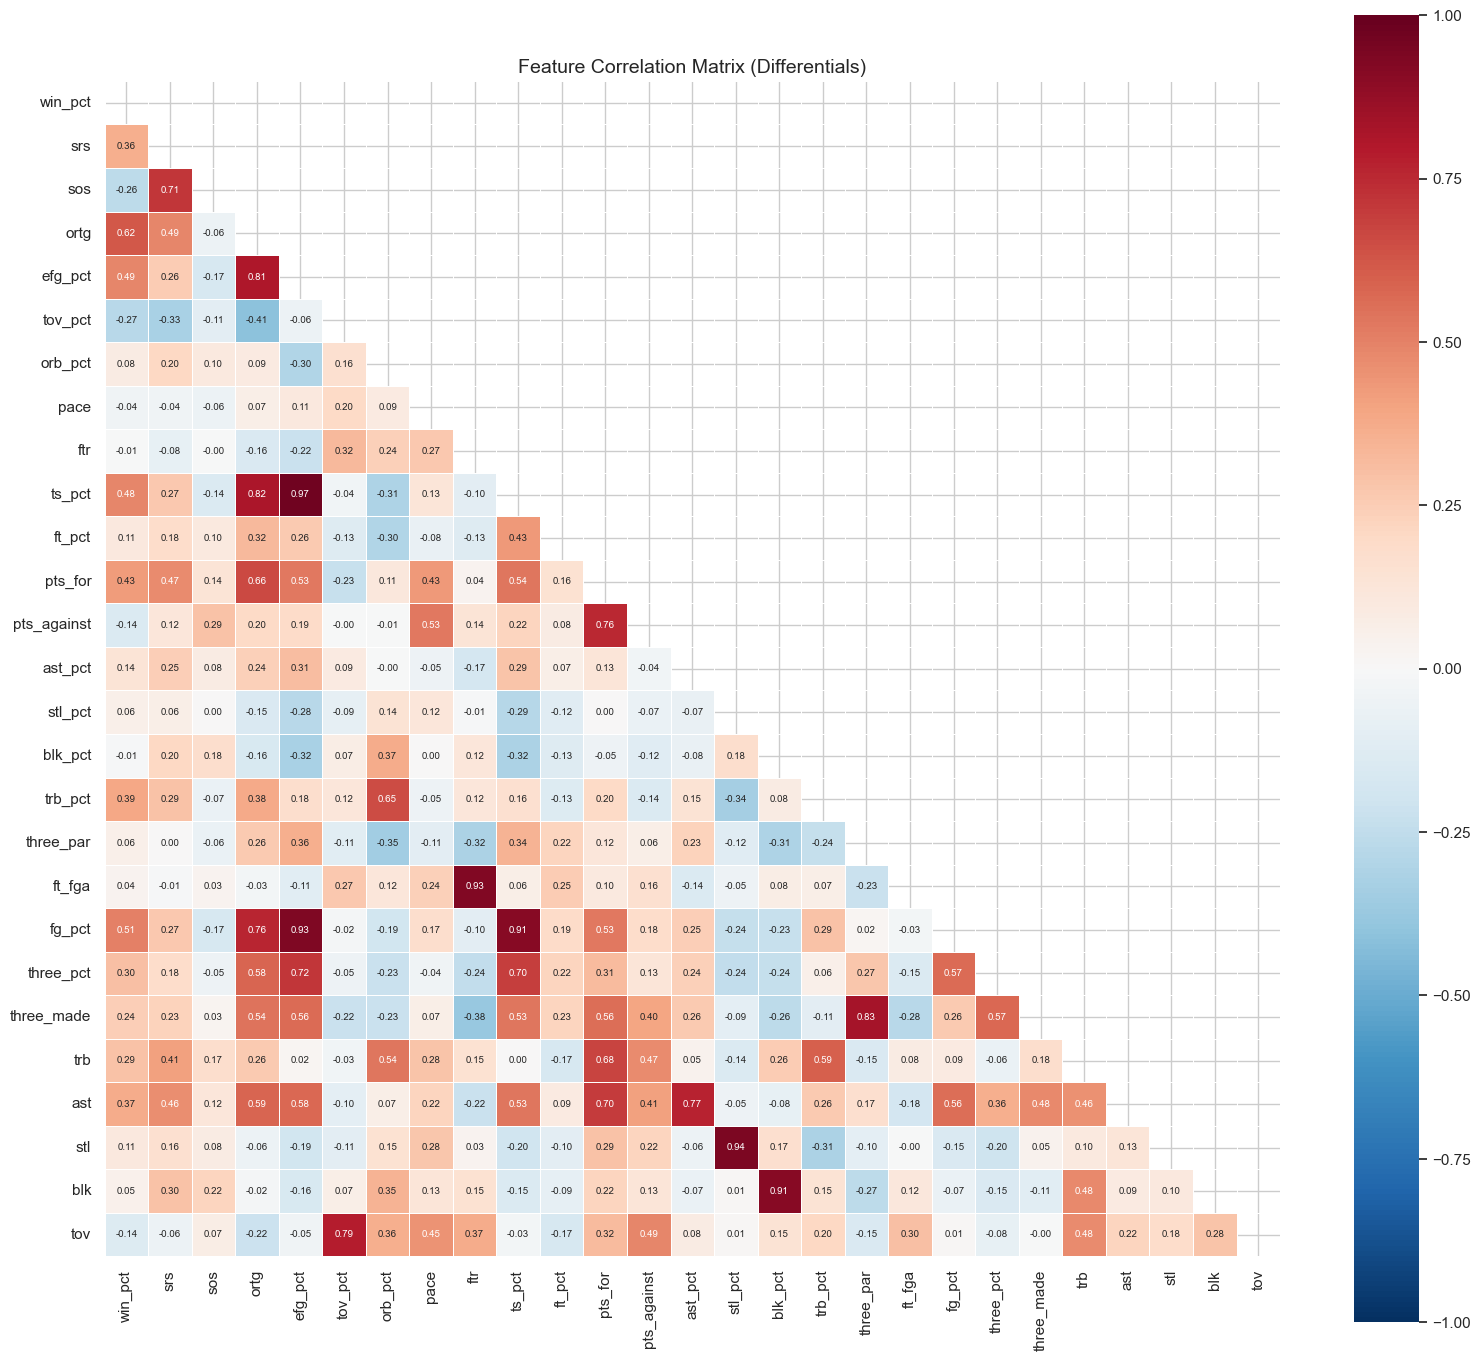

In [9]:
# Correlation matrix of all differential features
diff_df = df[diff_cols].copy()
diff_df.columns = [c.replace('diff_', '') for c in diff_df.columns]

corr_matrix = diff_df.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix (Differentials)', fontsize=14)
plt.tight_layout()
plt.savefig('../results/visualizations/correlations/feature_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Identify highly correlated feature pairs (|r| > 0.7)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

high_corr_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation'])
high_corr_df = high_corr_df.sort_values('Correlation', ascending=False, key=abs)
print(f'Highly correlated pairs (|r| > 0.7): {len(high_corr_df)}')
high_corr_df

Highly correlated pairs (|r| > 0.7): 16


,Feature 1,Feature 2,Correlation
4,efg_pct,ts_pct,0.974623
13,stl_pct,stl,0.942243
5,efg_pct,fg_pct,0.929903
8,ftr,ft_fga,0.926317
14,blk_pct,blk,0.911583
9,ts_pct,fg_pct,0.908727
15,three_par,three_made,0.829933
2,ortg,ts_pct,0.815117
1,ortg,efg_pct,0.811349
7,tov_pct,tov,0.786154


## 4. Feature Distributions: Winners vs Losers
How do the stat differentials differ between games where the home team wins vs loses?

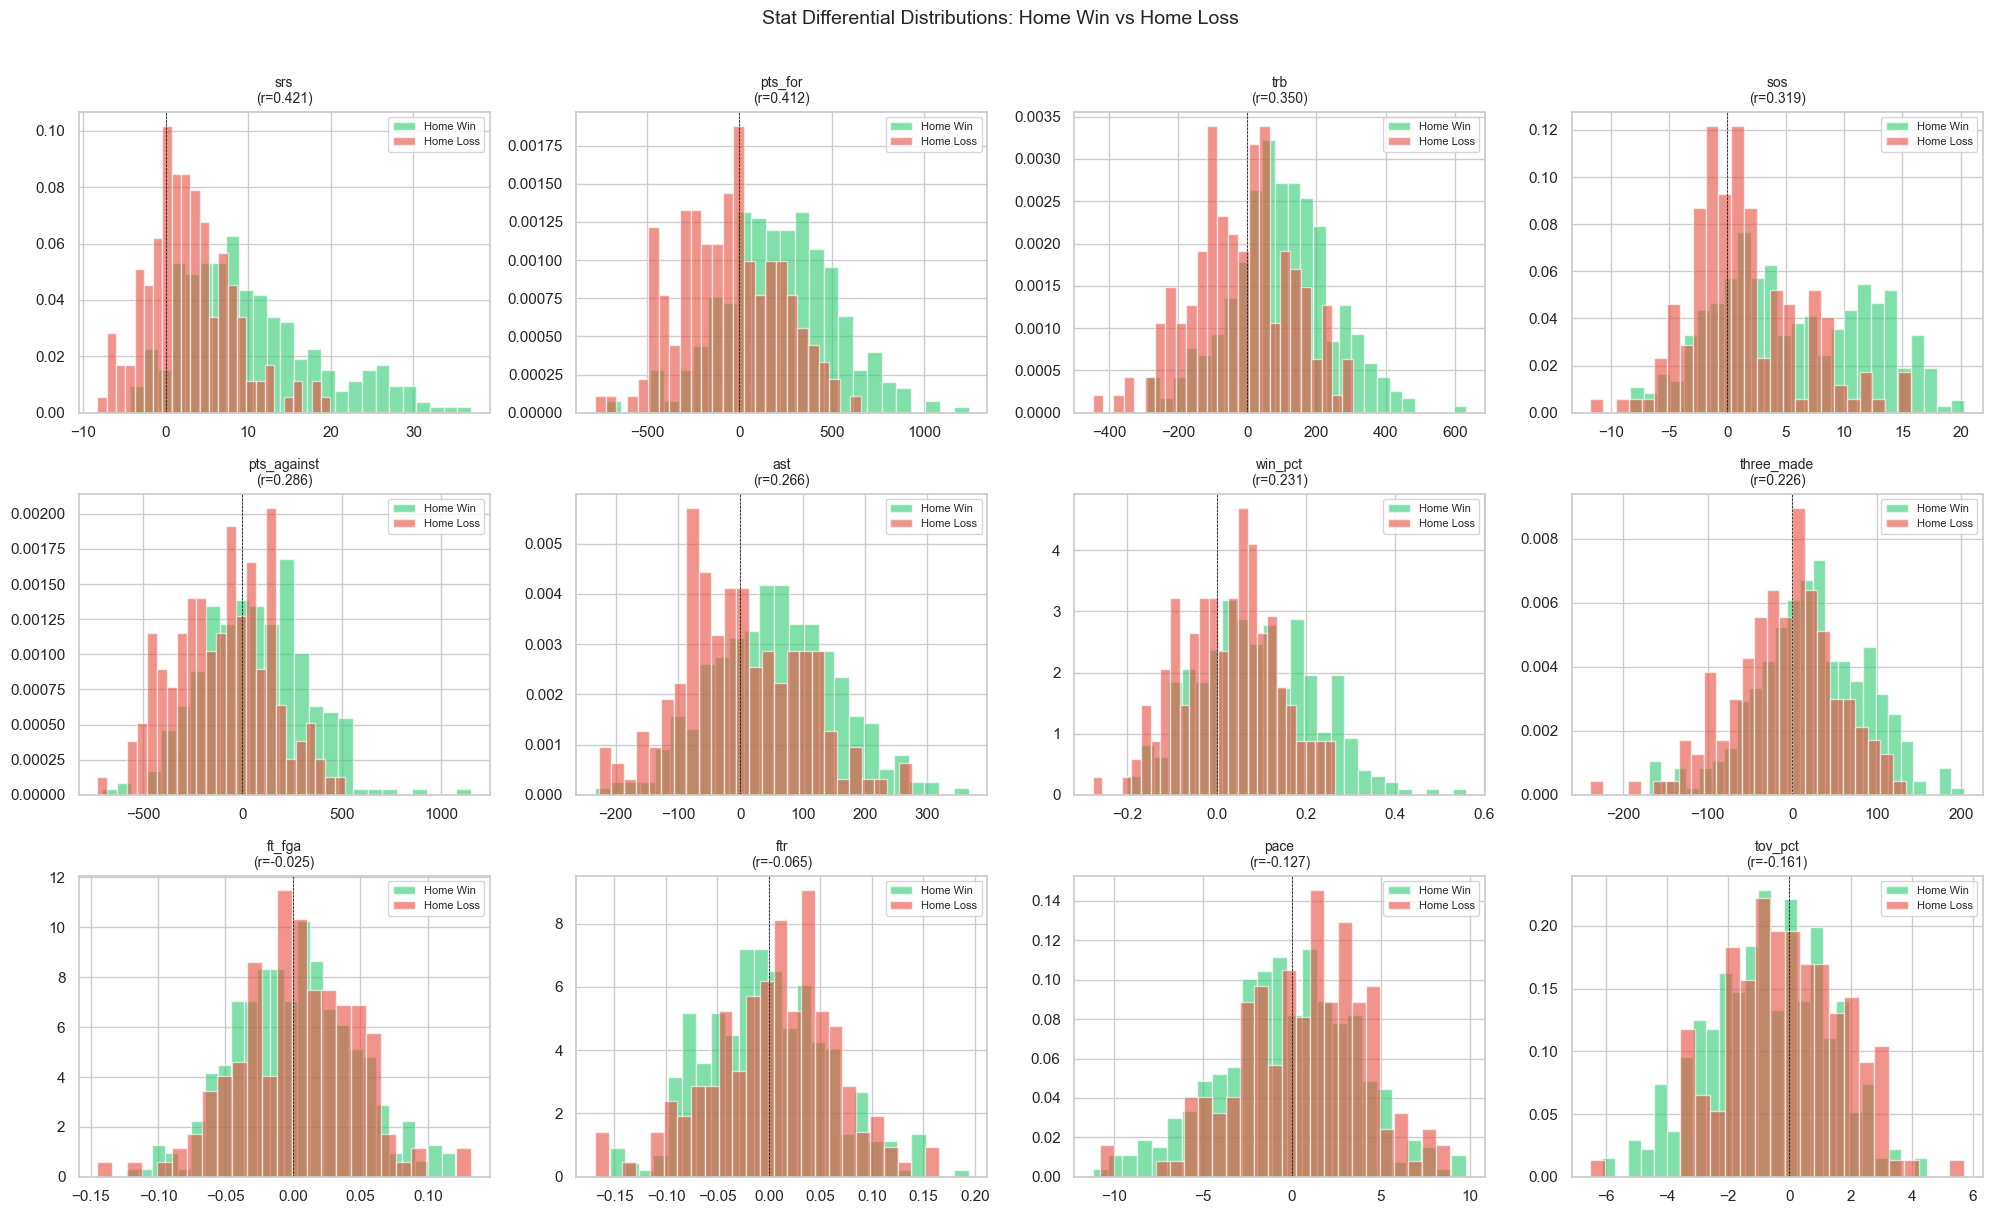

In [11]:
# Distribution plots for top features
top_features = correlations.head(8).index.tolist() + correlations.tail(4).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    col = f'diff_{feat}'
    
    wins = df[df['home_win'] == 1][col].dropna()
    losses = df[df['home_win'] == 0][col].dropna()
    
    ax.hist(wins, bins=25, alpha=0.6, label='Home Win', color='#2ecc71', density=True)
    ax.hist(losses, bins=25, alpha=0.6, label='Home Loss', color='#e74c3c', density=True)
    ax.set_title(f'{feat}\n(r={correlations[feat]:.3f})', fontsize=10)
    ax.legend(fontsize=8)
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')

for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Stat Differential Distributions: Home Win vs Home Loss', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/visualizations/distributions/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Tier Analysis
Compare the predictive power of Tier 1, Tier 2, and Tier 3 features.

In [12]:
tier1 = ['srs', 'win_pct', 'sos', 'ortg', 'efg_pct', 'tov_pct', 'orb_pct']
tier2 = ['pace', 'ftr', 'ts_pct', 'ft_pct', 'pts_for', 'pts_against']
tier3 = [c for c in STAT_COLS if c not in tier1 and c not in tier2]

# Average absolute correlation per tier
tier_data = []
for name, features in [('Tier 1: Strong', tier1), ('Tier 2: Context', tier2), ('Tier 3: Low Signal', tier3)]:
    abs_corrs = [abs(correlations[f]) for f in features if f in correlations.index]
    tier_data.append({
        'Tier': name,
        'Avg |Correlation|': np.mean(abs_corrs),
        'Max |Correlation|': np.max(abs_corrs),
        'Min |Correlation|': np.min(abs_corrs),
        'Features': len(features)
    })

tier_summary = pd.DataFrame(tier_data)
print('Tier Summary:')
tier_summary

Tier Summary:


,Tier,Avg |Correlation|,Max |Correlation|,Min |Correlation|,Features
0,Tier 1: Strong,0.211893,0.421247,0.044489,7
1,Tier 2: Context,0.186660,0.412141,0.065268,6
2,Tier 3: Low Signal,0.124851,0.349708,0.010730,14


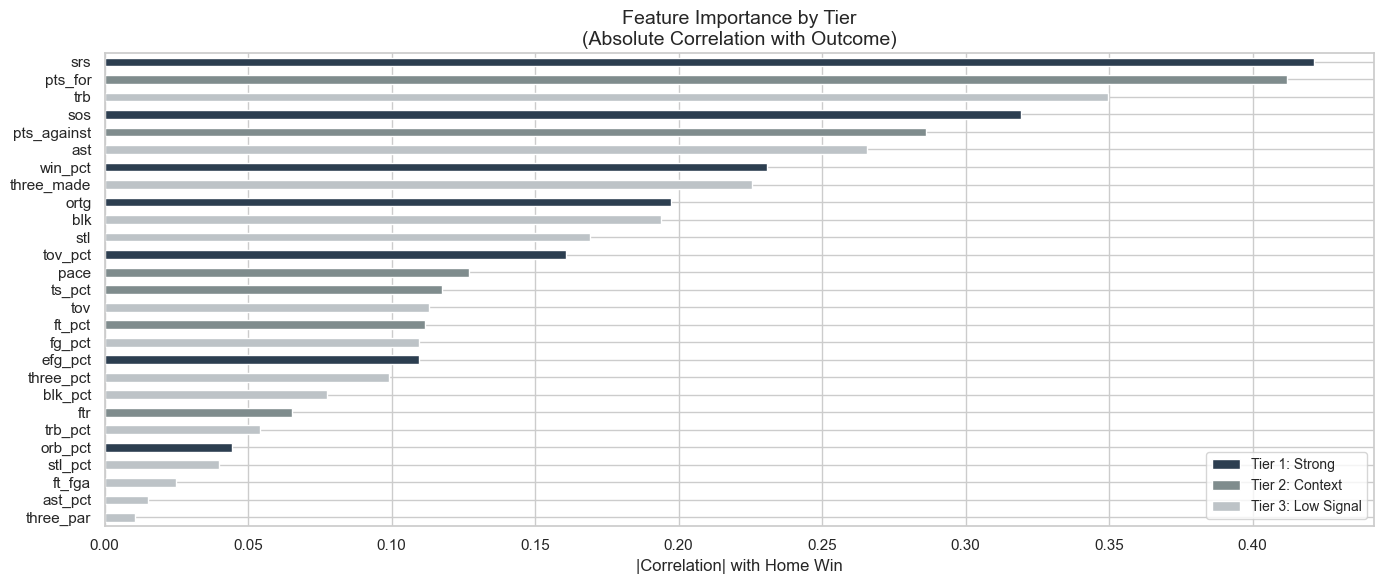

In [13]:
# Grouped bar chart by tier
fig, ax = plt.subplots(figsize=(14, 6))

tier_colors = {'Tier 1: Strong': '#2c3e50', 'Tier 2: Context': '#7f8c8d', 'Tier 3: Low Signal': '#bdc3c7'}
tier_labels = {f: 'Tier 1: Strong' for f in tier1}
tier_labels.update({f: 'Tier 2: Context' for f in tier2})
tier_labels.update({f: 'Tier 3: Low Signal' for f in tier3})

abs_corr = correlations.abs().sort_values(ascending=True)
colors = [tier_colors.get(tier_labels.get(f, ''), '#bdc3c7') for f in abs_corr.index]

abs_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('|Correlation| with Home Win', fontsize=12)
ax.set_title('Feature Importance by Tier\n(Absolute Correlation with Outcome)', fontsize=14)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../results/visualizations/feature_importance_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Seed Differential vs Features
How does seed differential compare to our stat-based features?

In [14]:
# Seed differential (lower seed = better, so away_seed - home_seed)
df['seed_diff'] = df['away_seed'] - df['home_seed']

seed_corr = df[['seed_diff', 'home_win']].corr().iloc[0, 1]
print(f'Seed differential correlation with home_win: {seed_corr:.4f}')
print(f'(Positive = higher-seeded home team more likely to win)')
print()

# Compare seed vs top stat features
print('Top features vs seed:')
print(f'  Seed diff:    {seed_corr:.4f}')
for feat in correlations.head(5).index:
    print(f'  {feat:15s} {correlations[feat]:.4f}')

Seed differential correlation with home_win: 0.3016
(Positive = higher-seeded home team more likely to win)

Top features vs seed:
  Seed diff:    0.3016
  srs             0.4212
  pts_for         0.4121
  trb             0.3497
  sos             0.3192
  pts_against     0.2862


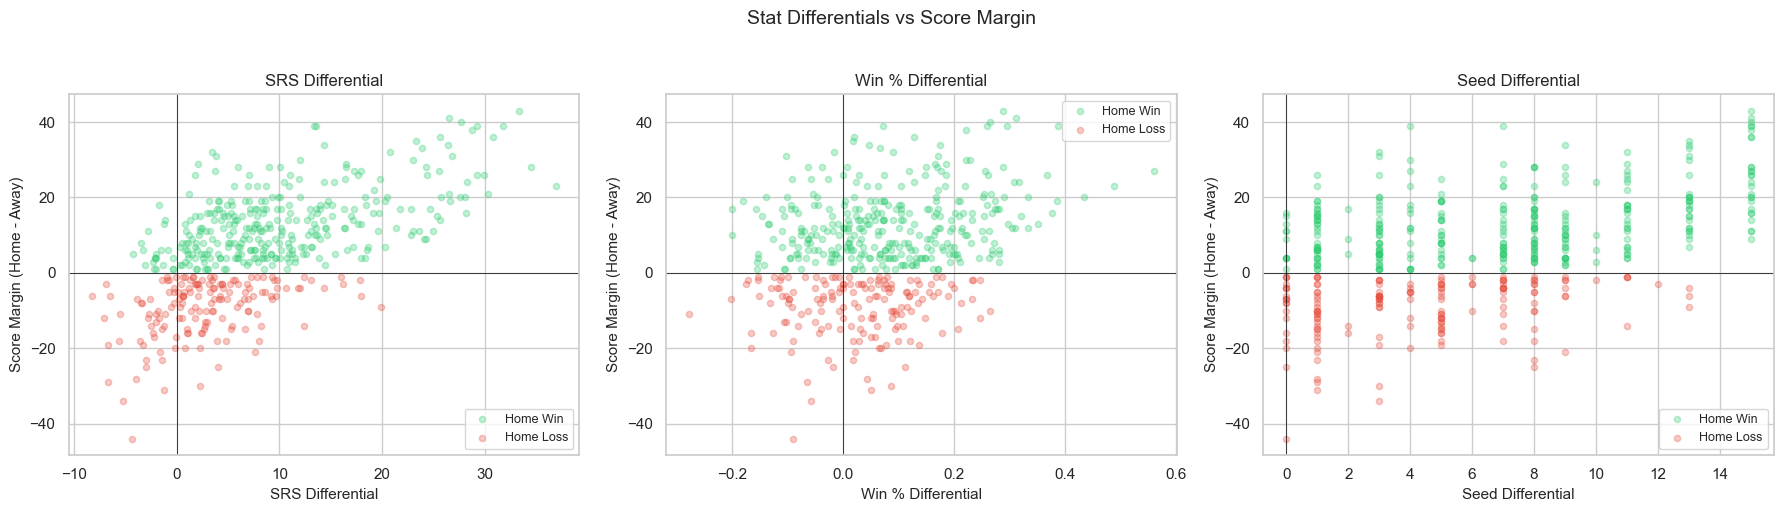

In [15]:
# Scatter: SRS differential vs game outcome
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat, title in zip(axes, 
    ['diff_srs', 'diff_win_pct', 'seed_diff'],
    ['SRS Differential', 'Win % Differential', 'Seed Differential']):
    
    wins = df[df['home_win'] == 1]
    losses = df[df['home_win'] == 0]
    
    ax.scatter(wins[feat], wins['home_score'] - wins['away_score'], 
               alpha=0.3, c='#2ecc71', label='Home Win', s=20)
    ax.scatter(losses[feat], losses['home_score'] - losses['away_score'], 
               alpha=0.3, c='#e74c3c', label='Home Loss', s=20)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Score Margin (Home - Away)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Stat Differentials vs Score Margin', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/visualizations/tournament_analysis/stat_vs_margin.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary & Feature Recommendations

In [16]:
# Final summary table
summary = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
    '|Correlation|': correlations.abs().values,
    'Tier': [tier_labels.get(f, 'Unknown') for f in correlations.index]
})
summary = summary.sort_values('|Correlation|', ascending=False).reset_index(drop=True)
summary.index += 1
summary.index.name = 'Rank'

print('Feature Rankings by Predictive Power')
print('='*60)
summary

Feature Rankings by Predictive Power


,Feature,Correlation,|Correlation|,Tier
Rank,,,,
1,srs,0.421247,0.421247,Tier 1: Strong
2,pts_for,0.412141,0.412141,Tier 2: Context
3,trb,0.349708,0.349708,Tier 3: Low Signal
4,sos,0.319207,0.319207,Tier 1: Strong
5,pts_against,0.286206,0.286206,Tier 2: Context
6,ast,0.265709,0.265709,Tier 3: Low Signal
7,win_pct,0.230919,0.230919,Tier 1: Strong
8,three_made,0.225694,0.225694,Tier 3: Low Signal
9,ortg,0.197303,0.197303,Tier 1: Strong


In [17]:
# Save the processed matchup data for modeling
output_path = Path('../data/processed')
output_path.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path / 'tournament_matchups.csv', index=False)
print(f'Saved {len(df)} matchups to {output_path / "tournament_matchups.csv"}')
print(f'Columns: {len(df.columns)}')
print(f'Seasons: {sorted(df["season"].unique())}')

Saved 477 matchups to ..\data\processed\tournament_matchups.csv
Columns: 91
Seasons: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
